## CMA-ES vs Gradient methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import cma
import time

### 1. Introduction
This notebook aims to explore how the Covariance Matrix Adaptation Evolution Strategy (CMA-ES), a powerful gradient-free optimization algorithm, can be used to "train" the weights of a simple neural network. We will apply it to a binary classification problem.

The primary goal is not to showcase CMA-ES as the best method for standard neural network training. Instead, it's to:

- Demonstrate that it can optimize neural network weights by directly optimizing for a metric like accuracy (which can be seen as a non-differentiable objective from a certain perspective).
- Critically compare its performance (accuracy, computational effort) against a standard gradient-based training method (like Adam, as used in scikit-learn's MLPClassifier).
- Encourage you to be "suspicious" and ask critical questions when you encounter non-gradient methods being used for standard, differentiable neural network training tasks where gradient-based methods are well-established and highly efficient.

### 2. The Dataset: Two Moons
We'll use the "Two Moons" dataset, a classic non-linearly separable binary classification problem.

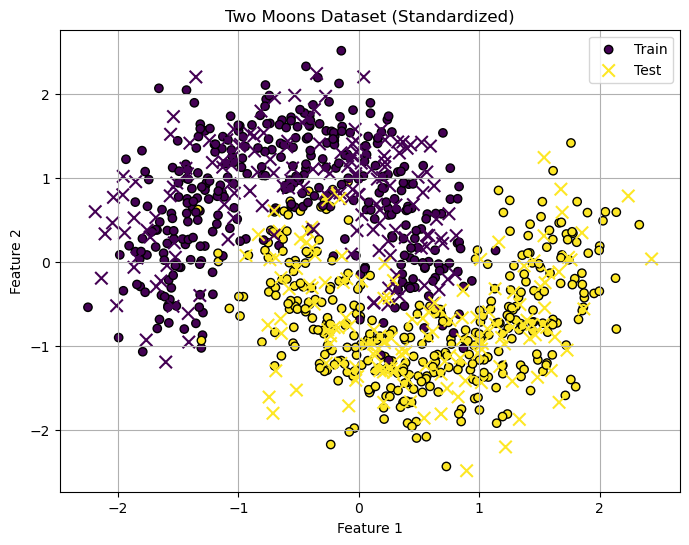

Training set shape: X=(700, 2), y=(700,)
Test set shape: X=(300, 2), y=(300,)


In [2]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolors="k", label="Train"
)
plt.scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, marker="x", s=80, label="Test"
)
plt.title("Two Moons Dataset (Standardized)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Training set shape: X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test_scaled.shape}, y={y_test.shape}")

# Komentarz
Na wykresie widać zbiór Two Moons po standaryzacji danych. Klasy tworzą dwa nieliniowo rozdzielne 'księżyce', więc prosty klasyfikator liniowy nie wystarczyłby do dobrego podziału. Dane zostały podzielone na zbiór treningowy 700 próbek i testowy 300 próbek.

### 3. Neural Network Definition
We will use a simple feedforward neural network with:

Input layer: 2 neurons (for our 2D data) <br>
Hidden layer: `N_HIDDEN_NODES` neurons with tanh activation. You can start with `N_HIDDEN_NODES=32` <br>
Output layer: 1 neuron with sigmoid activation (for binary classification probability) <br>
The parameters (weights and biases) of this network will be flattened into a single vector for CMA-ES to optimize.

In [3]:
N_INPUT_NODES = X_train_scaled.shape[1]
N_HIDDEN_NODES = 128
N_OUTPUT_NODES = 1

# Calculate the total number of parameters (D)
# Weights W1: N_INPUT x N_HIDDEN
# Biases b1: N_HIDDEN
# Weights W2: N_HIDDEN x N_OUTPUT
# Biases b2: N_OUTPUT
D = (N_INPUT_NODES * N_HIDDEN_NODES) + N_HIDDEN_NODES + \
    (N_HIDDEN_NODES * N_OUTPUT_NODES) + N_OUTPUT_NODES

print(f"Neural Network Architecture:")
print(f"Input Layer: {N_INPUT_NODES} neurons")
print(f"Hidden Layer: {N_HIDDEN_NODES} neurons (tanh activation)")
print(f"Output Layer: {N_OUTPUT_NODES} neuron (sigmoid activation)")
print(f"Total number of parameters (weights & biases) to optimize: D = {D}")

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def nn_forward_pass(params_vector: np.ndarray, X_data: np.ndarray) -> np.ndarray:
    idx_end_W1 = N_INPUT_NODES * N_HIDDEN_NODES
    W1 = params_vector[0:idx_end_W1].reshape(N_INPUT_NODES, N_HIDDEN_NODES)

    idx_end_b1 = idx_end_W1 + N_HIDDEN_NODES
    b1 = params_vector[idx_end_W1:idx_end_b1]

    idx_end_W2 = idx_end_b1 + (N_HIDDEN_NODES * N_OUTPUT_NODES)
    W2 = params_vector[idx_end_b1:idx_end_W2].reshape(N_HIDDEN_NODES, N_OUTPUT_NODES)

    b2 = params_vector[idx_end_W2:]

    # Hidden layer
    hidden_layer_input = np.dot(X_data, W1) + b1
    hidden_layer_output = tanh(hidden_layer_input)

    # Output layer
    output_layer_input = np.dot(hidden_layer_output, W2) + b2
    output = sigmoid(output_layer_input)

    return output

Neural Network Architecture:
Input Layer: 2 neurons
Hidden Layer: 128 neurons (tanh activation)
Output Layer: 1 neuron (sigmoid activation)
Total number of parameters (weights & biases) to optimize: D = 513


# Komentarz
Sieć ma 2 neurony wejściowe, jedną warstwę ukrytą z funkcją tanh oraz jeden neuron wyjściowy z funkcją sigmoid, ponieważ jest to klasyfikacja binarna. Przy 128 neuronach ukrytych sieć ma 513 parametrów, które CMA-ES będzie optymalizować jako jeden długi wektor wag i biasów.

### 4. Training with CMA-ES
We have to define a fitness function that CMA-ES will try to minimize. Since our goal is to maximize accuracy, our fitness will be 1.0 - accuracy.

The accuracy is calculated by:
- Performing a forward pass with the given parameters.
- Thresholding the sigmoid output (e.g., > 0.5 means class 1, else class 0).
- Comparing predicted classes to true labels.
- This direct use of accuracy (based on a hard threshold) makes the objective effectively non-differentiable with respect to the network parameters if one were to try to use calculus directly without a surrogate like cross-entropy.

In [4]:
def cma_fitness(params_vector: np.ndarray) -> float:
    y_proba = nn_forward_pass(params_vector, X_train_scaled).ravel()
    y_pred = (y_proba > 0.5).astype(int)
    acc = accuracy_score(y_train, y_pred)

    # CMA-ES minimalizuje, a my chcemy maksymalizować accuracy
    return 1.0 - acc


sigma0 = 0.5
max_generations = 100

x0 = np.random.randn(D) * 0.1

es = cma.CMAEvolutionStrategy(
    x0,
    sigma0,
    {
        "verbose": -9
    }
)

best_fitness_history = []
best_accuracy_history = []

start_time = time.time()

for generation in range(max_generations):
    solutions = es.ask()

    fitness_values = [
        cma_fitness(np.array(solution))
        for solution in solutions
    ]

    es.tell(solutions, fitness_values)

    best_fitness = min(fitness_values)
    best_accuracy = 1.0 - best_fitness

    best_fitness_history.append(best_fitness)
    best_accuracy_history.append(best_accuracy)

    if generation % 10 == 0:
        print(
            f"Generation {generation}: "
            f"best accuracy = {best_accuracy:.4f}, "
            f"best fitness = {best_fitness:.4f}"
        )

end_time = time.time()

best_params_cma = es.result.xbest

train_proba = nn_forward_pass(best_params_cma, X_train_scaled).ravel()
train_pred = (train_proba > 0.5).astype(int)
train_acc_cma = accuracy_score(y_train, train_pred)

test_proba = nn_forward_pass(best_params_cma, X_test_scaled).ravel()
test_pred = (test_proba > 0.5).astype(int)
test_acc_cma = accuracy_score(y_test, test_pred)

print(f"\nCMA-ES training time: {end_time - start_time:.2f} s")
print(f"Train accuracy CMA-ES: {train_acc_cma:.4f}")
print(f"Test accuracy CMA-ES: {test_acc_cma:.4f}")

Generation 0: best accuracy = 0.8729, best fitness = 0.1271
Generation 10: best accuracy = 0.8643, best fitness = 0.1357
Generation 20: best accuracy = 0.8700, best fitness = 0.1300
Generation 30: best accuracy = 0.8729, best fitness = 0.1271
Generation 40: best accuracy = 0.9143, best fitness = 0.0857
Generation 50: best accuracy = 0.9329, best fitness = 0.0671
Generation 60: best accuracy = 0.9329, best fitness = 0.0671
Generation 70: best accuracy = 0.9371, best fitness = 0.0629
Generation 80: best accuracy = 0.9371, best fitness = 0.0629
Generation 90: best accuracy = 0.9371, best fitness = 0.0629

CMA-ES training time: 16.60 s
Train accuracy CMA-ES: 0.9457
Test accuracy CMA-ES: 0.9567


# Komentarze
CMA-ES stopniowo poprawiał jakość klasyfikacji. Ostatecznie najlepszy znaleziony model uzyskał bardzo dobre wyniki (94-95% na obydwu zbiorach). To pokazuje, że CMA-ES skutecznie dobrał wagi sieci neuronowej bez użycia klasycznej propagacji wstecznej.

### Visualizing the Decision Boundary (CMA-ES)
Let's see how the decision boundary learned by the CMA-ES-trained network looks.

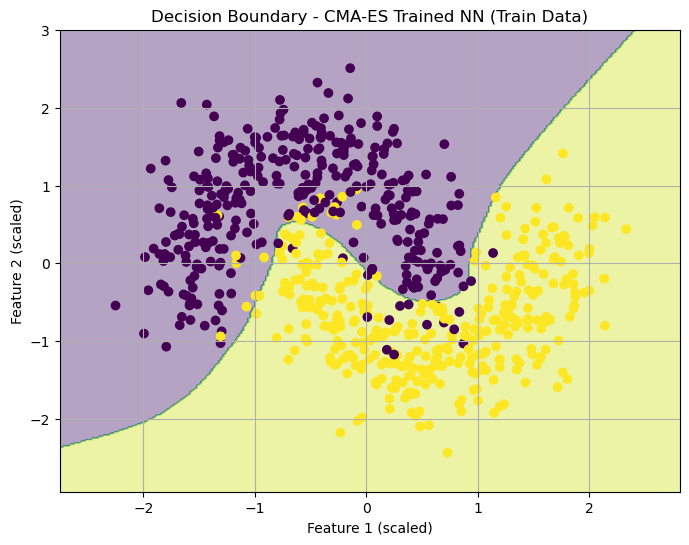

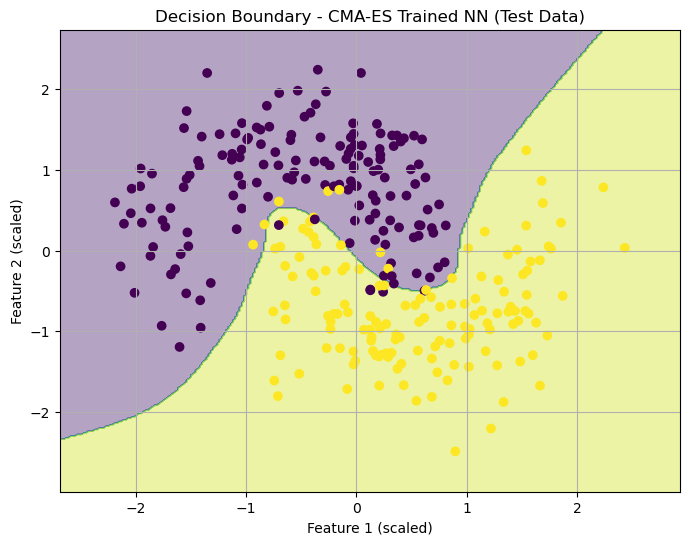

In [5]:
def plot_decision_boundary(pred_func, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = .02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z_proba = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z_proba > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=.4)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    plt.grid(True)
    plt.show()

cma_pred_func = lambda x_data: nn_forward_pass(best_params_cma, x_data)

plot_decision_boundary(cma_pred_func, X_train_scaled, y_train, "Decision Boundary - CMA-ES Trained NN (Train Data)")
plot_decision_boundary(cma_pred_func, X_test_scaled, y_test, "Decision Boundary - CMA-ES Trained NN (Test Data)")

# Komentarz
Na wykresach widać, że granica decyzyjna dobrze dopasowała się do nieliniowego kształtu zbioru Two Moons. Model nie tworzy prostej linii, tylko zakrzywioną granicę, która oddziela dwie klasy. Wyniki na danych testowych są podobne do treningowych, więc nie widać silnego przeuczenia.

### 5. Training with a Standard Gradient-Based Method
Now, let's train a neural network with the same architecture using a standard gradient-based optimizer. You can use `scikit-learn`'s `MLPClassifier`, which employs optimizers like 'adam' or 'sgd' and uses a differentiable loss function (like cross-entropy) internally. Display decision boundary for a trained model.

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(N_HIDDEN_NODES,),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

end_time = time.time()

train_pred_mlp = mlp.predict(X_train_scaled)
test_pred_mlp = mlp.predict(X_test_scaled)

train_acc_mlp = accuracy_score(y_train, train_pred_mlp)
test_acc_mlp = accuracy_score(y_test, test_pred_mlp)

print(f"MLPClassifier training time: {end_time - start_time:.2f} s")
print(f"Train accuracy MLPClassifier: {train_acc_mlp:.4f}")
print(f"Test accuracy MLPClassifier: {test_acc_mlp:.4f}")

MLPClassifier training time: 0.45 s
Train accuracy MLPClassifier: 0.8557
Test accuracy MLPClassifier: 0.8700


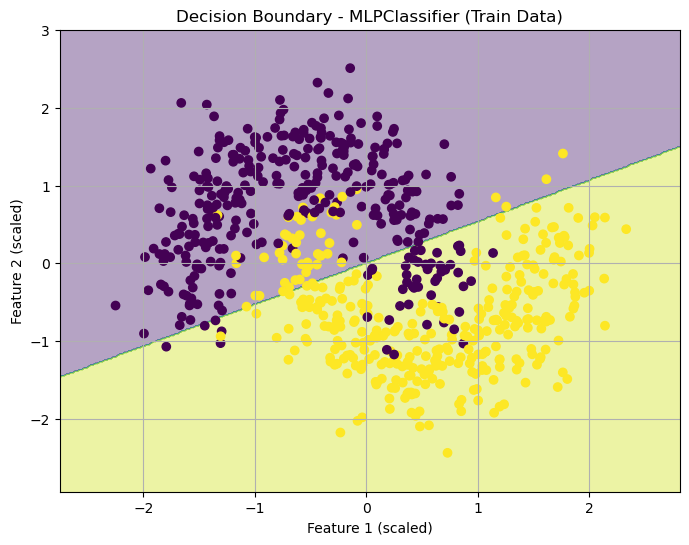

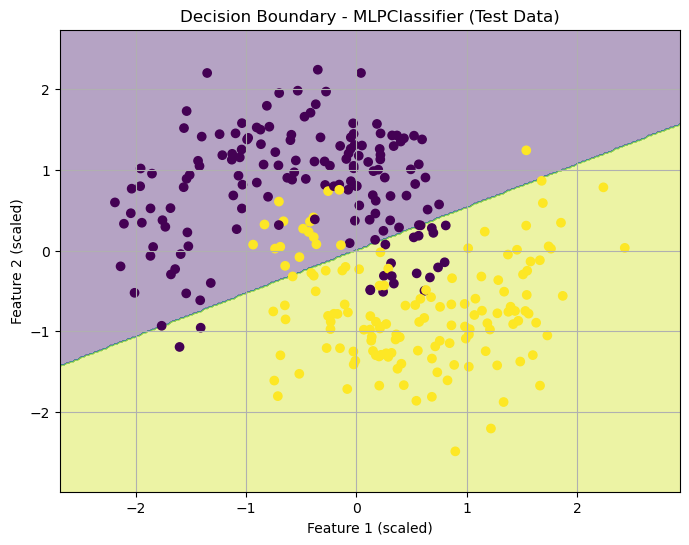

In [7]:
mlp_pred_func = lambda x_data: mlp.predict_proba(x_data)[:, 1]

plot_decision_boundary(
    mlp_pred_func,
    X_train_scaled,
    y_train,
    "Decision Boundary - MLPClassifier (Train Data)"
)

plot_decision_boundary(
    mlp_pred_func,
    X_test_scaled,
    y_test,
    "Decision Boundary - MLPClassifier (Test Data)"
)

# Komentarz
### Podstawowy MLPClassifier
MLPClassifier trenował się bardzo szybko, około 0.45 s, ale osiągnął słabszą dokładność niż CMA-ES: 85.57% na treningu i 87.00% na teście. Granica decyzyjna jest prawie liniowa, więc model nie dopasował dobrze nieliniowego kształtu zbioru Two Moons.

### Exercise 1

Compare the performance of CMA-ES and MLPClassifier across varying hidden layer sizes (e.g., 8, 16, 32, 64). Evaluate both methods in terms of training time and the quality of the resulting models, using appropriate performance metrics.

In [8]:
import pandas as pd

def count_params(hidden: int) -> int:
    return (
        N_INPUT_NODES * hidden
        + hidden
        + hidden * N_OUTPUT_NODES
        + N_OUTPUT_NODES
    )


def nn_forward_pass_hidden(params_vector: np.ndarray, X_data: np.ndarray, hidden: int) -> np.ndarray:
    idx_end_W1 = N_INPUT_NODES * hidden
    W1 = params_vector[0:idx_end_W1].reshape(N_INPUT_NODES, hidden)

    idx_end_b1 = idx_end_W1 + hidden
    b1 = params_vector[idx_end_W1:idx_end_b1]

    idx_end_W2 = idx_end_b1 + hidden * N_OUTPUT_NODES
    W2 = params_vector[idx_end_b1:idx_end_W2].reshape(hidden, N_OUTPUT_NODES)

    b2 = params_vector[idx_end_W2:]

    hidden_output = np.tanh(np.dot(X_data, W1) + b1)
    output = sigmoid(np.dot(hidden_output, W2) + b2)

    return output


def train_cma_hidden(hidden: int, max_generations: int = 80, sigma0: float = 0.5, seed: int = 42) -> dict:
    D_hidden = count_params(hidden)
    rng = np.random.default_rng(seed)
    x0 = rng.normal(0, 0.1, D_hidden)

    def fitness(params_vector):
        y_proba = nn_forward_pass_hidden(np.asarray(params_vector), X_train_scaled, hidden).ravel()
        y_pred = (y_proba > 0.5).astype(int)
        acc = accuracy_score(y_train, y_pred)
        return 1.0 - acc

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "verbose": -9,
            "seed": seed
        }
    )

    start = time.time()

    for _ in range(max_generations):
        solutions = es.ask()
        fitness_values = [fitness(solution) for solution in solutions]
        es.tell(solutions, fitness_values)

    end = time.time()

    best_params = np.asarray(es.result.xbest)

    train_pred = (nn_forward_pass_hidden(best_params, X_train_scaled, hidden).ravel() > 0.5).astype(int)
    test_pred = (nn_forward_pass_hidden(best_params, X_test_scaled, hidden).ravel() > 0.5).astype(int)

    return {
        "method": "CMA-ES",
        "hidden": hidden,
        "params": D_hidden,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "time": end - start
    }


def train_mlp_hidden(hidden: int, max_iter: int = 1000, seed: int = 42) -> dict:
    start = time.time()

    clf = MLPClassifier(
        hidden_layer_sizes=(hidden,),
        activation="tanh",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=max_iter,
        random_state=seed
    )

    clf.fit(X_train_scaled, y_train)

    end = time.time()

    train_pred = clf.predict(X_train_scaled)
    test_pred = clf.predict(X_test_scaled)

    return {
        "method": "MLPClassifier",
        "hidden": hidden,
        "params": count_params(hidden),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "time": end - start
    }


hidden_sizes = [8, 16, 32, 64]

comparison_results = []

for hidden in hidden_sizes:
    comparison_results.append(train_cma_hidden(hidden, max_generations=80))
    comparison_results.append(train_mlp_hidden(hidden, max_iter=1000))

comparison_df = pd.DataFrame(comparison_results)
comparison_df

C:\Users\wesol\anaconda3\envs\DataScience\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,method,hidden,params,train_accuracy,test_accuracy,time
0,CMA-ES,8,33,0.947143,0.946667,1.939687
1,MLPClassifier,8,33,0.934286,0.930000,3.583148
2,CMA-ES,16,65,0.947143,0.956667,2.770615
3,MLPClassifier,16,65,0.857143,0.863333,1.042232
4,CMA-ES,32,129,0.941429,0.943333,4.459890
5,MLPClassifier,32,129,0.858571,0.866667,0.508304
6,CMA-ES,64,257,0.950000,0.953333,7.995003
7,MLPClassifier,64,257,0.855714,0.866667,0.355854


# Komentarz
### Porównanie CMA-ES i MLPClassifier dla różnych rozmiarów warstwy ukrytej
CMA-ES uzyskał lepszą dokładność testową dla wszystkich badanych rozmiarów warstwy ukrytej. Najlepszy wynik CMA-ES pojawił się dla 16 neuronów ukrytych. MLPClassifier był zwykle szybszy, szczególnie dla większych sieci, ale jego dokładność zatrzymała się na poziomie około 86-93%.

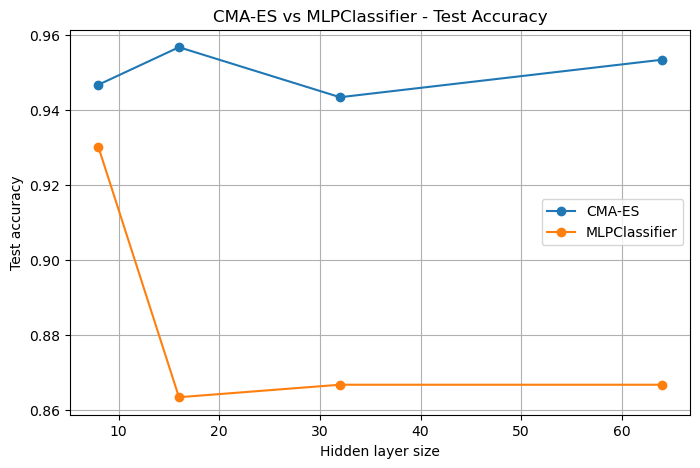

In [9]:
plt.figure(figsize=(8, 5))

for method in comparison_df["method"].unique():
    subset = comparison_df[comparison_df["method"] == method]
    plt.plot(subset["hidden"], subset["test_accuracy"], marker="o", label=method)

plt.xlabel("Hidden layer size")
plt.ylabel("Test accuracy")
plt.title("CMA-ES vs MLPClassifier - Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Komentarz
### Wykres dokładności
Wykres pokazuje, że CMA-ES daje stabilnie wysoką skuteczność niezależnie od liczby neuronów ukrytych. MLPClassifier osiągnął dobry wynik tylko dla najmniejszej sieci, a później jego jakość spadła. Oznacza to, że domyślne ustawienia MLPClassifier nie były dobrze dopasowane do tego zadania.

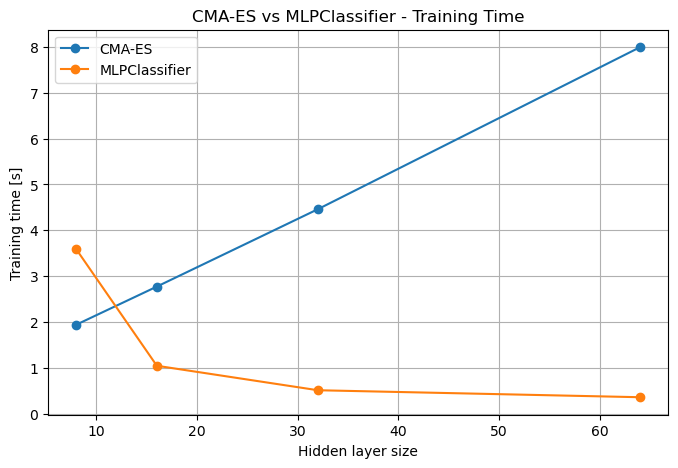

In [10]:
plt.figure(figsize=(8, 5))

for method in comparison_df["method"].unique():
    subset = comparison_df[comparison_df["method"] == method]
    plt.plot(subset["hidden"], subset["time"], marker="o", label=method)

plt.xlabel("Hidden layer size")
plt.ylabel("Training time [s]")
plt.title("CMA-ES vs MLPClassifier - Training Time")
plt.legend()
plt.grid(True)
plt.show()

# Komentarz
### Wykres czasu trenowania
Czas trenowania CMA-ES rośnie wraz z liczbą parametrów, co jest oczekiwane, ponieważ algorytm musi optymalizować coraz większy wektor wag. MLPClassifier był znacznie szybszy dla większych sieci, ponieważ korzysta z metody gradientowej. Pokazuje to, że CMA-ES może dawać dobre wyniki, ale jest bardziej kosztowny obliczeniowo.

### Exercise 2

Improve the hyperparameters of the `MLPClassifier`, with particular attention to the learning rate, the maximum number of iterations, and other relevant training parameters. Your objective is to achieve performance that surpasses that of the CMA-ES baseline.

In [11]:
from sklearn.model_selection import ParameterGrid

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

param_grid = {
    "learning_rate_init": [0.0005, 0.001, 0.003, 0.01],
    "max_iter": [1000, 2000],
    "alpha": [0.00001, 0.0001, 0.001]
}

tuning_results = []

best_val_acc = -np.inf
best_params = None

for params in ParameterGrid(param_grid):
    clf = MLPClassifier(
        hidden_layer_sizes=(N_HIDDEN_NODES,),
        activation="tanh",
        solver="adam",
        random_state=42,
        **params
    )

    start = time.time()
    clf.fit(X_tr, y_tr)
    end = time.time()

    val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    tuning_results.append({
        **params,
        "val_accuracy": val_acc,
        "time": end - start
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("val_accuracy", ascending=False).head()

,alpha,learning_rate_init,max_iter,val_accuracy,time
6,0.00001,0.01,1000,0.957143,1.395696
7,0.00001,0.01,2000,0.957143,1.472517
15,0.00010,0.01,2000,0.957143,1.520002
14,0.00010,0.01,1000,0.957143,1.486789
22,0.00100,0.01,1000,0.957143,1.513748


# Komentarz
### Strojenie hiperparametrów MLPClassifier
Po dostrojeniu model osiągnął 94.57% na treningu i 94.67% na teście, czyli znacznie lepiej niż podstawowy MLPClassifier. Jednak nadal nie przebił wyniku CMA-ES, który na teście miał 95.67%.

In [12]:
print("Best params:", best_params)
print("Best validation accuracy:", best_val_acc)

start = time.time()

best_mlp = MLPClassifier(
    hidden_layer_sizes=(N_HIDDEN_NODES,),
    activation="tanh",
    solver="adam",
    random_state=42,
    **best_params
)

best_mlp.fit(X_train_scaled, y_train)

end = time.time()

train_pred_best_mlp = best_mlp.predict(X_train_scaled)
test_pred_best_mlp = best_mlp.predict(X_test_scaled)

train_acc_best_mlp = accuracy_score(y_train, train_pred_best_mlp)
test_acc_best_mlp = accuracy_score(y_test, test_pred_best_mlp)

print(f"Tuned MLP training time: {end - start:.2f} s")
print(f"Tuned MLP train accuracy: {train_acc_best_mlp:.4f}")
print(f"Tuned MLP test accuracy: {test_acc_best_mlp:.4f}")

print(f"CMA-ES test accuracy baseline: {test_acc_cma:.4f}")

Best params: {'alpha': 1e-05, 'learning_rate_init': 0.01, 'max_iter': 1000}
Best validation accuracy: 0.9571428571428572
Tuned MLP training time: 1.66 s
Tuned MLP train accuracy: 0.9457
Tuned MLP test accuracy: 0.9467
CMA-ES test accuracy baseline: 0.9567


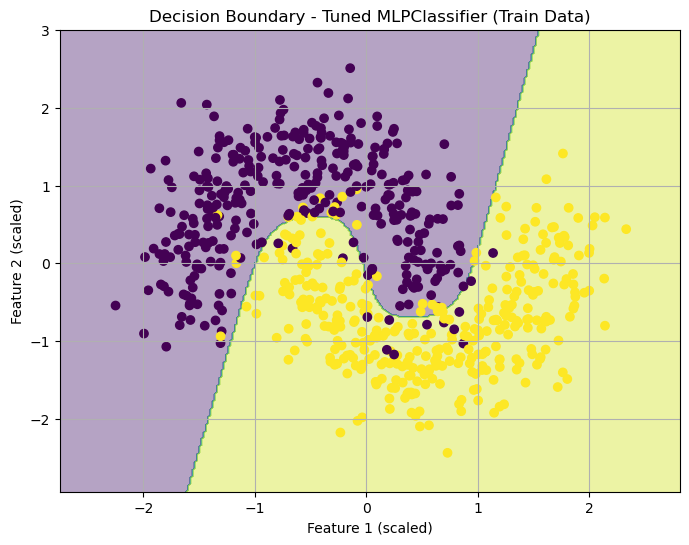

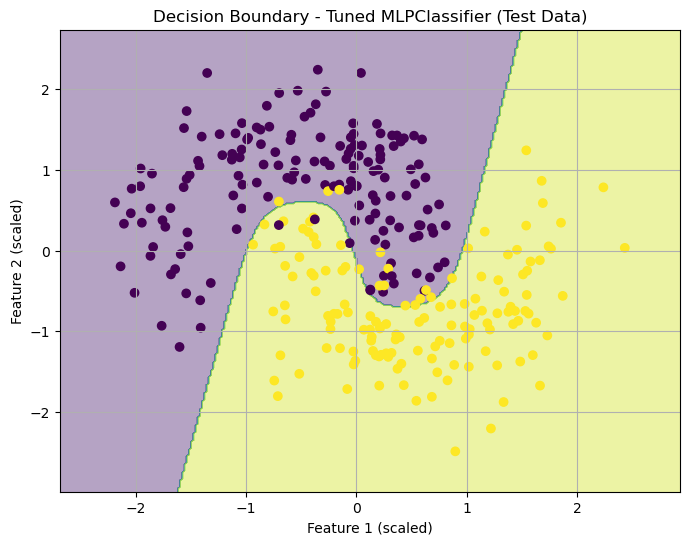

In [13]:
best_mlp_pred_func = lambda x_data: best_mlp.predict_proba(x_data)[:, 1]

plot_decision_boundary(
    best_mlp_pred_func,
    X_train_scaled,
    y_train,
    "Decision Boundary - Tuned MLPClassifier (Train Data)"
)

plot_decision_boundary(
    best_mlp_pred_func,
    X_test_scaled,
    y_test,
    "Decision Boundary - Tuned MLPClassifier (Test Data)"
)

# Komentarz
### Granica decyzyjna po tuningu
Po dostrojeniu hiperparametrów granica decyzyjna MLPClassifier jest dużo bardziej zakrzywiona i lepiej dopasowana do kształtu danych. Model lepiej rozdziela dwa księżyce niż podstawowa wersja MLPClassifier. Nadal jednak widać kilka błędnych klasyfikacji w środkowej części zbioru, gdzie klasy mocno się mieszają.

### Exercise 3
Read the article titled "Artykuł" available on UPeL, and provide a critical analysis of its content.

# Komentarz
Artykuł dotyczy trenowania sieci neuronowych za pomocą PSO oraz nowej metody inicjalizacji populacji opartej na rozkładzie log-logistic. Autorzy wskazują, że standardowe PSO zwykle inicjalizuje cząstki losowo z rozkładu jednostajnego, a dobór punktów początkowych może wpływać na jakość i szybkość optymalizacji. Zaproponowana metoda PSOLL-NN została porównana z BPA, standardowym PSO-NN oraz wariantami PSO wykorzystującymi sekwencje Halton, Torus i Sobol.

Mocną stroną artykułu jest to, że autorzy testują metodę na kilku zbiorach danych UCI i porównują ją z kilkoma wariantami algorytmów. Według wyników PSOLL-NN często osiąga najlepszą dokładność testową, np. dla zbiorów Horse, Vertebral, Wine, Diabetes, Blood Tissue, Seed i Heart.

Trzeba jednak podejść do wyników ostrożnie. W artykule brakuje dokładniejszej analizy statystycznej, np. odchyleń standardowych, testów istotności i jasnej informacji o wielu powtórzeniach eksperymentu. Nie pokazano też dokładnie kosztu obliczeniowego metod, a porównanie z klasycznym BPA nie jest tak przekonujące jak porównanie z nowoczesnymi optymalizatorami typu Adam. Dodatkowo część tabel i opisów jest mało czytelna, co utrudnia pełną ocenę jakości eksperymentu.

Wniosek z artykułu jest zgodny z ideą laboratoriów: algorytmy populacyjne mogą trenować sieci neuronowe bez klasycznego gradientu. Nie oznacza to jednak, że są najlepszym wyborem dla standardowych problemów klasyfikacji. W praktyce, jeśli model i funkcja straty są różniczkowalne, metody gradientowe zwykle są szybsze i łatwiejsze do skalowania, natomiast PSO lub CMA-ES mogą być ciekawą alternatywą dla problemów niedyferencjowalnych, zaszumionych lub trudnych do opisania klasyczną funkcją straty.